<a href="https://colab.research.google.com/github/carlos3113/challenge-1/blob/main/Challange1_CZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [15]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda1.head()


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [6]:
for i, df in enumerate([tienda1, tienda2, tienda3, tienda4], start=1):
    print(f"\n===== TIENDA {i} =====")
    print(df.info())
    print("\nNulos por columna:")
    print(df.isna().sum())


===== TIENDA 1 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB
None

Nulos por columna:
Producto                  0
Categoría de

In [16]:
def resumen_facturacion(df, nombre_tienda, col_precio='Precio', col_cantidad='Cantidad de cuotas'):
    df = df.copy()
    df['facturacion'] = df[col_precio] * df[col_cantidad]
    total = df['facturacion'].sum()
    return {'Tienda': nombre_tienda, 'Facturacion_Total': total}

res_fact = []
res_fact.append(resumen_facturacion(tienda1, 'Tienda 1'))
res_fact.append(resumen_facturacion(tienda2, 'Tienda 2'))
res_fact.append(resumen_facturacion(tienda3, 'Tienda 3'))
res_fact.append(resumen_facturacion(tienda4, 'Tienda 4'))

df_facturacion = pd.DataFrame(res_fact)
df_facturacion

,Tienda,Facturacion_Total
0,Tienda 1,3.422718e+09
1,Tienda 2,3.337189e+09
2,Tienda 3,3.243817e+09
3,Tienda 4,3.098827e+09


In [10]:
df_facturacion_ordenado = df_facturacion.sort_values('Facturacion_Total', ascending=False)
df_facturacion_ordenado

,Tienda,Facturacion_Total
0,Tienda 1,3.422718e+09
1,Tienda 2,3.337189e+09
2,Tienda 3,3.243817e+09
3,Tienda 4,3.098827e+09


/tmp/ipykernel_468/1483758232.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


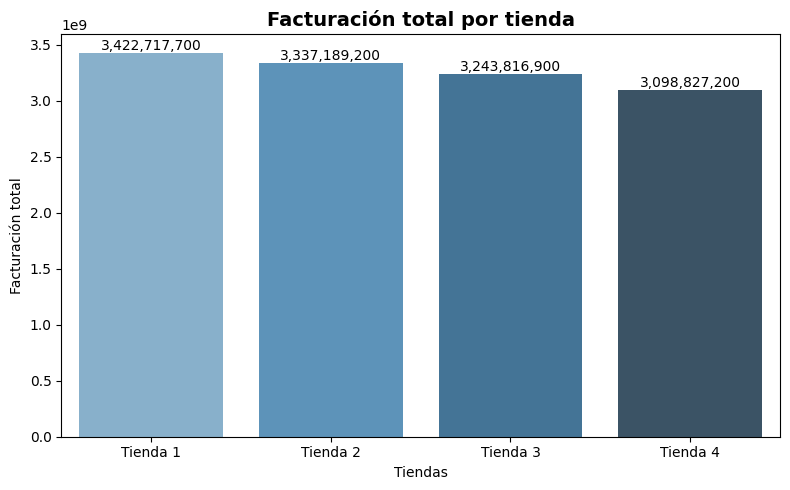

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Si aún no lo tienes ordenado:
df_facturacion_ordenado = df_facturacion.sort_values('Facturacion_Total', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_facturacion_ordenado,
    x='Tienda',
    y='Facturacion_Total',
    palette='Blues_d'
)

plt.title('Facturación total por tienda', fontsize=14, fontweight='bold')
plt.xlabel('Tiendas')
plt.ylabel('Facturación total')

# Etiquetas de valor encima de cada barra
for index, row in df_facturacion_ordenado.iterrows():
    plt.text(
        x=index,
        y=row['Facturacion_Total'],
        s=f"{row['Facturacion_Total']:,.0f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()


# 2. Ventas por categoría

In [17]:
def ventas_por_categoria(df, nombre_tienda, col_categoria='Categoría del Producto', col_precio='Precio', col_cantidad='Cantidad de cuotas'):
    df = df.copy()
    df['facturacion'] = df[col_precio] * df[col_cantidad]

    ventas_cat = df.groupby(col_categoria).agg({
        col_cantidad: 'sum',
        'facturacion': 'sum'
    }).reset_index()
    ventas_cat.columns = ['Categoria', 'Cantidad_Total', 'Facturacion_Total']
    ventas_cat['Ticket_Promedio'] = ventas_cat['Facturacion_Total'] / ventas_cat['Cantidad_Total']
    ventas_cat['%_Facturacion'] = ventas_cat['Facturacion_Total'] / ventas_cat['Facturacion_Total'].sum() * 100
    ventas_cat = ventas_cat.sort_values('Facturacion_Total', ascending=False)

    return ventas_cat.head(10)  # Top 10 categorías

# Aplicar a cada tienda
cat1 = ventas_por_categoria(tienda1, 'Tienda 1')
cat2 = ventas_por_categoria(tienda2, 'Tienda 2')
cat3 = ventas_por_categoria(tienda3, 'Tienda 3')
cat4 = ventas_por_categoria(tienda4, 'Tienda 4')

print("Tienda 1:\n", cat1)
print("\nTienda 2:\n", cat2)

Tienda 1:
                  Categoria  Cantidad_Total  Facturacion_Total  \
3             Electrónicos            1341       1.290391e+09   
2        Electrodomésticos             906       1.032376e+09   
7                  Muebles            1446       5.829282e+08   
4   Instrumentos musicales             573       2.769905e+08   
1     Deportes y diversión             796       1.268837e+08   
5                 Juguetes             872       4.906280e+07   
0  Artículos para el hogar             489       3.831680e+07   
6                   Libros             520       2.576940e+07   

   Ticket_Promedio  %_Facturacion  
3     9.622600e+05      37.700763  
2     1.139487e+06      30.162452  
7     4.031315e+05      17.031150  
4     4.834040e+05       8.092707  
1     1.594016e+05       3.707104  
5     5.626468e+04       1.433446  
0     7.835746e+04       1.119485  
6     4.955654e+04       0.752893  

Tienda 2:
                  Categoria  Cantidad_Total  Facturacion_Total  \
3 

In [18]:
print("\nTienda 3:\n", cat3)
print("\nTienda 4:\n", cat4)


Tienda 3:
                  Categoria  Cantidad_Total  Facturacion_Total  \
3             Electrónicos            1262       1.101334e+09   
2        Electrodomésticos             882       1.081381e+09   
7                  Muebles            1408       5.550925e+08   
4   Instrumentos musicales             580       2.503360e+08   
1     Deportes y diversión             873       1.233992e+08   
5                 Juguetes             937       6.119040e+07   
0  Artículos para el hogar             542       4.472460e+07   
6                   Libros             517       2.635890e+07   

   Ticket_Promedio  %_Facturacion  
3     8.726898e+05      33.951808  
2     1.226055e+06      33.336678  
7     3.942418e+05      17.112325  
4     4.316138e+05       7.717328  
1     1.413507e+05       3.804136  
5     6.530459e+04       1.886370  
0     8.251771e+04       1.378765  
6     5.098433e+04       0.812589  

Tienda 4:
                  Categoria  Cantidad_Total  Facturacion_Total  \
3

In [19]:
categorias_top = pd.concat([cat1, cat2, cat3, cat4], ignore_index=True)
categorias_top = categorias_top.groupby('Categoria')['Facturacion_Total'].sum().sort_values(ascending=False).head(10).reset_index()

In [20]:
df_pivot = pd.concat([
    cat1.assign(Tienda='Tienda 1'),
    cat2.assign(Tienda='Tienda 2'),
    cat3.assign(Tienda='Tienda 3'),
    cat4.assign(Tienda='Tienda 4')
]).pivot(index='Categoria', columns='Tienda', values='Facturacion_Total').fillna(0)
df_pivot

Tienda,Tienda 1,Tienda 2,Tienda 3,Tienda 4
Categoria,,,,
Artículos para el hogar,3.831680e+07,4.273970e+07,4.472460e+07,4.457930e+07
Deportes y diversión,1.268837e+08,8.166060e+07,1.233992e+08,1.000620e+08
Electrodomésticos,1.032376e+09,1.026226e+09,1.081381e+09,8.790896e+08
Electrónicos,1.290391e+09,1.286644e+09,1.101334e+09,1.211446e+09
Instrumentos musicales,2.769905e+08,2.944487e+08,2.503360e+08,2.228372e+08
Juguetes,4.906280e+07,4.672120e+07,6.119040e+07,5.464120e+07
Libros,2.576940e+07,3.141700e+07,2.635890e+07,2.954340e+07
Muebles,5.829282e+08,5.273321e+08,5.550925e+08,5.566280e+08


<Figure size 1200x800 with 0 Axes>

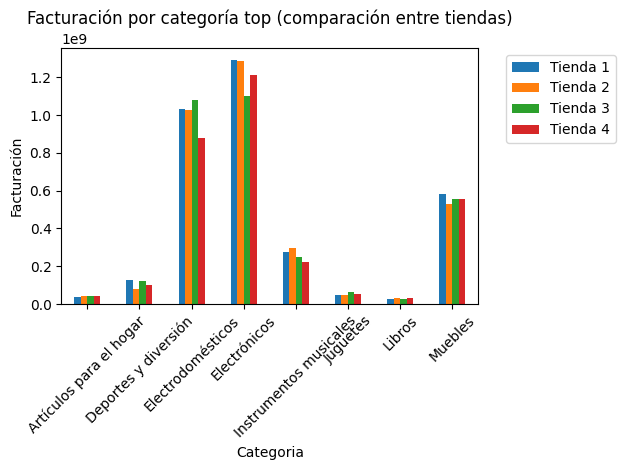

In [21]:
plt.figure(figsize=(12, 8))
df_pivot.head(8).plot(kind='bar', stacked=False)
plt.title('Facturación por categoría top (comparación entre tiendas)')
plt.ylabel('Facturación')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 3. Calificación promedio de la tienda


In [25]:
def analisis_calificaciones(df, nombre_tienda, col_calif='Calificación'):
    if col_calif not in df.columns:
        print(f"Columna '{col_calif}' no encontrada en {nombre_tienda}")
        return None

    df_calif = df[col_calif].dropna()

    resumen = {
        'Tienda': nombre_tienda,
        'Calificacion_Promedio': df_calif.mean(),
        'Calificacion_Mediana': df_calif.median(),
        'Num_Reseñas': len(df_calif),
        '%_Bajas_Calif': (df_calif <= 3).mean() * 100,  # % notas <=3
        '%_Altas_Calif': (df_calif >= 4).mean() * 100   # % notas >=4
    }

    return pd.DataFrame([resumen])

# Aplicar a cada tienda
calif1 = analisis_calificaciones(tienda1, 'Tienda 1')
calif2 = analisis_calificaciones(tienda2, 'Tienda 2')
calif3 = analisis_calificaciones(tienda3, 'Tienda 3')
calif4 = analisis_calificaciones(tienda4, 'Tienda 4')
df_calificaciones = pd.concat([calif1, calif2, calif3, calif4], ignore_index=True)
df_calificaciones

,Tienda,Calificacion_Promedio,Calificacion_Mediana,Num_Reseñas,%_Bajas_Calif,%_Altas_Calif
0,Tienda 1,3.976685,5.0,2359,26.409496,73.590504
1,Tienda 2,4.037304,5.0,2359,24.374735,75.625265
2,Tienda 3,4.048326,5.0,2359,24.120390,75.879610
3,Tienda 4,3.995759,5.0,2358,25.657337,74.342663


In [26]:
df_calif_ordenado = df_calificaciones.sort_values('Calificacion_Promedio', ascending=False)
df_calif_ordenado

,Tienda,Calificacion_Promedio,Calificacion_Mediana,Num_Reseñas,%_Bajas_Calif,%_Altas_Calif
2,Tienda 3,4.048326,5.0,2359,24.120390,75.879610
1,Tienda 2,4.037304,5.0,2359,24.374735,75.625265
3,Tienda 4,3.995759,5.0,2358,25.657337,74.342663
0,Tienda 1,3.976685,5.0,2359,26.409496,73.590504


/tmp/ipykernel_468/479366955.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


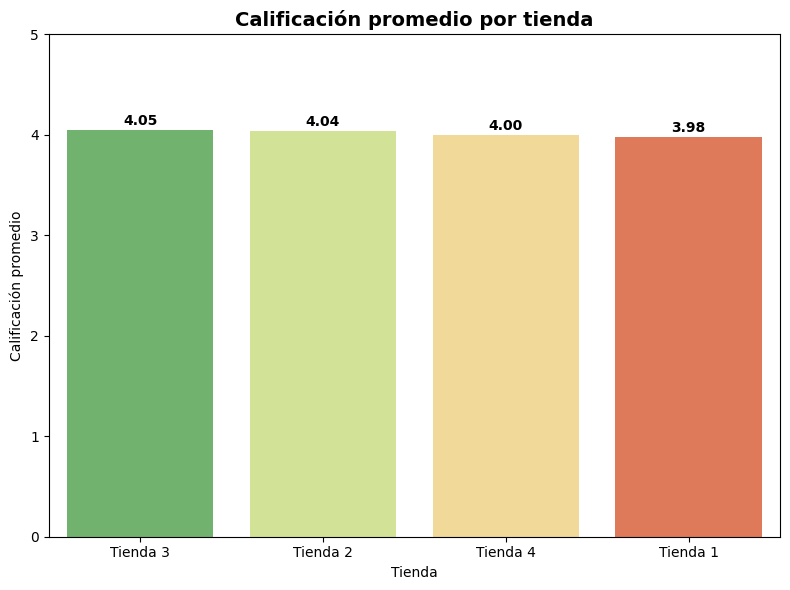

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(
    data=df_calif_ordenado,
    x='Tienda',
    y='Calificacion_Promedio',
    palette='RdYlGn_r'  # Verde para altas, rojo para bajas
)

plt.title('Calificación promedio por tienda', fontsize=14, fontweight='bold')
plt.ylabel('Calificación promedio')

# Etiquetas con valores
for i, row in enumerate(df_calif_ordenado.itertuples()):
    plt.text(i, row.Calificacion_Promedio + 0.05, f"{row.Calificacion_Promedio:.2f}",
             ha='center', fontweight='bold')

plt.ylim(0, 5)  # Ajusta si escala es 0-10
plt.tight_layout()
plt.show()

# 4. Productos más y menos vendidos

In [30]:
def top_productos(df, nombre_tienda, col_producto='Producto', col_precio='Precio', col_cantidad='Cantidad de cuotas'):
    df = df.copy()
    df['facturacion'] = df[col_precio] * df[col_cantidad]

    # Top 10 más vendidos (unidades)
    top_vendidos = df.groupby(col_producto).agg({
        col_cantidad: 'sum',
        'facturacion': 'sum'
    }).reset_index()
    top_vendidos.columns = ['Producto', 'Unidades_Vendidas', 'Facturacion']
    top_vendidos['Participacion_%'] = top_vendidos['Facturacion'] / top_vendidos['Facturacion'].sum() * 100
    top10 = top_vendidos.nlargest(10, 'Unidades_Vendidas')

    # Bottom 10 menos vendidos
    bottom10 = top_vendidos.nsmallest(10, 'Unidades_Vendidas')

    return top10, bottom10

# Aplicar a cada tienda
top1, bottom1 = top_productos(tienda1, 'Tienda 1')
top2, bottom2 = top_productos(tienda2, 'Tienda 2')
top3, bottom3 = top_productos(tienda3, 'Tienda 3')
top4, bottom4 = top_productos(tienda4, 'Tienda 4')

print("=== TOP 10 PRODUCTOS TIENDA 1 ===")
print(top1)
print("\n=== BOTTOM 10 TIENDA 1 ===")
print(bottom1)

=== TOP 10 PRODUCTOS TIENDA 1 ===
                   Producto  Unidades_Vendidas  Facturacion  Participacion_%
40         Secadora de ropa                214  216848800.0         6.335574
48            TV LED UHD 4K                196  451704100.0        13.197235
32            Mesa de noche                188   52406800.0         1.531146
23                Impresora                182   56029000.0         1.636974
8                 Bicicleta                178   95319900.0         2.784919
5       Balón de baloncesto                167    8647400.0         0.252647
22       Guitarra eléctrica                167  132461600.0         3.870071
47          Sofá reclinable                163  109106100.0         3.187704
9   Bloques de construcción                161    5115100.0         0.149446
43         Silla de oficina                161   62991800.0         1.840403

=== BOTTOM 10 TIENDA 1 ===
                     Producto  Unidades_Vendidas  Facturacion  Participacion_%
13          

/tmp/ipykernel_468/1842942374.py:16: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  bars = sns.barplot(


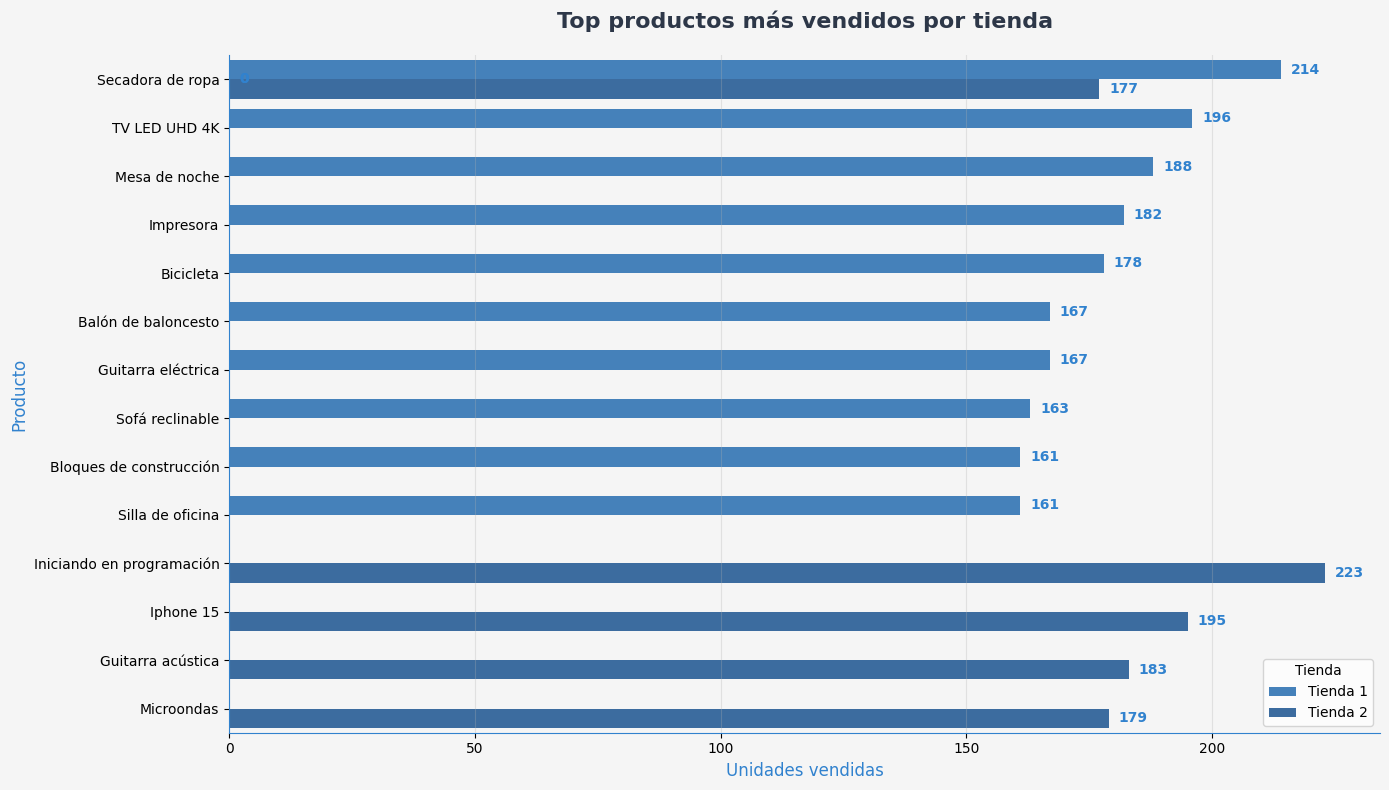

In [36]:
GRIS_1 = '#F5F5F5'
AZUL_1 = '#3182CE'
ROJO_1 = '#C53030'


top_all = pd.concat([top1.assign(Tienda='Tienda 1'), top2.assign(Tienda='Tienda 2'),
                     top3.assign(Tienda='Tienda 3'), top4.assign(Tienda='Tienda 4')])

top_all_filtrado = top_all[top_all['Unidades_Vendidas'] > 0].head(15)

plt.figure(figsize=(14, 8), facecolor=GRIS_1)
ax = plt.gca()
ax.set_facecolor(GRIS_1)

# Gráfico horizontal con valores
bars = sns.barplot(
    data=top_all_filtrado,
    x='Unidades_Vendidas',
    y='Producto',
    hue='Tienda',
    palette=['#3182CE', '#2B6CB0', '#2C5282', '#2A4365']
)

plt.title('Top productos más vendidos por tienda', fontsize=16, fontweight='bold', pad=20, color='#2D3748')
plt.xlabel('Unidades vendidas', fontsize=12, color=AZUL_1)
plt.ylabel('Producto', fontsize=12, color=AZUL_1)

# AGREGAR VALORES NUMÉRICOS EN CADA BARRA
for i, bar in enumerate(bars.patches):
    width = bar.get_width()
    plt.text(
        width + 2, bar.get_y() + bar.get_height()/2,
        f'{int(width):,}',
        ha='left', va='center',
        fontsize=10, fontweight='bold', color=AZUL_1
    )

# Estilo limpio
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(AZUL_1)
ax.spines['bottom'].set_color(AZUL_1)
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

In [41]:
def analisis_envio(df, nombre_tienda, col_costo_envio='Costo de envío', col_tiempo_envio='tiempo_envio'):
    resumen = {'Tienda': nombre_tienda}

    # Costo promedio envío
    if col_costo_envio in df.columns:
        df_envio = df[df[col_costo_envio] > 0]  # Solo envíos con costo
        resumen['Costo_Promedio_Envio'] = df_envio[col_costo_envio].mean()
        resumen['Num_Envios'] = len(df_envio)
        resumen['Costo_Total_Envio'] = df_envio[col_costo_envio].sum()
    else:
        resumen['Costo_Promedio_Envio'] = 0
        resumen['Num_Envios'] = 0

    # Tiempo promedio envío
    if col_tiempo_envio in df.columns:
        df_tiempo = df[df[col_tiempo_envio] > 0]
        resumen['Tiempo_Promedio_Envio'] = df_tiempo[col_tiempo_envio].mean()
    else:
        resumen['Tiempo_Promedio_Envio'] = 0

    return pd.DataFrame([resumen])

In [42]:
envio1 = analisis_envio(tienda1, 'Tienda 1')
envio2 = analisis_envio(tienda2, 'Tienda 2')
envio3 = analisis_envio(tienda3, 'Tienda 3')
envio4 = analisis_envio(tienda4, 'Tienda 4')

df_envios = pd.concat([envio1, envio2, envio3, envio4], ignore_index=True)
df_envios

,Tienda,Costo_Promedio_Envio,Num_Envios,Costo_Total_Envio,Tiempo_Promedio_Envio
0,Tienda 1,28547.860465,2150,61377900.0,0
1,Tienda 2,27731.981352,2145,59485100.0,0
2,Tienda 3,27204.370060,2151,58516600.0,0
3,Tienda 4,25586.216466,2162,55317400.0,0


/tmp/ipykernel_468/2978010962.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_envios, x='Tienda', y='Costo_Promedio_Envio', palette='Reds_d')


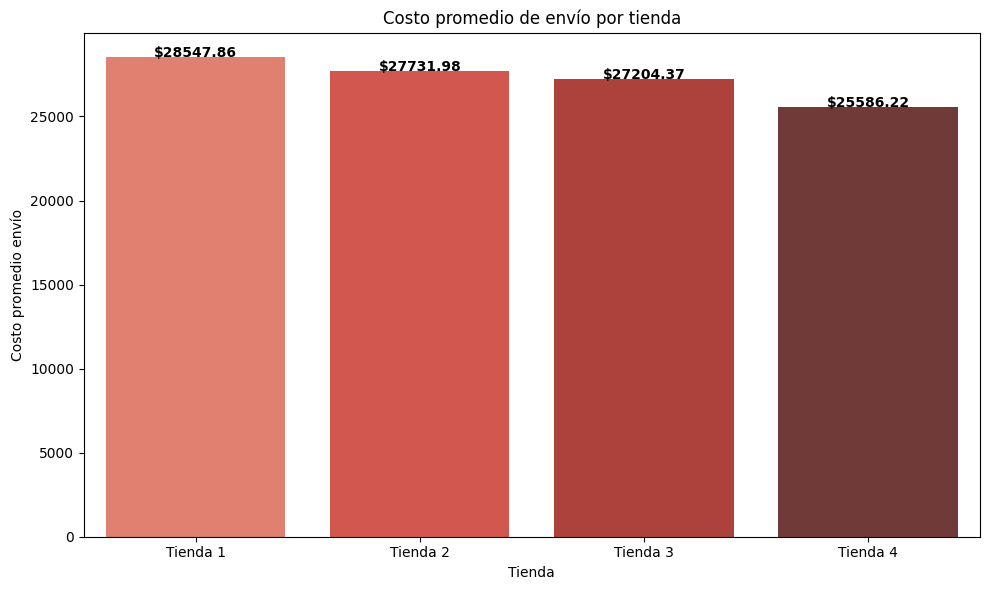

In [43]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_envios, x='Tienda', y='Costo_Promedio_Envio', palette='Reds_d')
plt.title('Costo promedio de envío por tienda')
plt.ylabel('Costo promedio envío')

for i, row in df_envios.iterrows():
    plt.text(i, row['Costo_Promedio_Envio'] + 0.1, f"${row['Costo_Promedio_Envio']:.2f}",
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [45]:
df_real = pd.DataFrame({
    'Tienda': ['T1','T2','T3','T4'],
    'Facturacion': [3.422718e9,3.337189e9,3.243817e9,3.098827e9],
    'Calificacion': [3.976685,4.037304,4.048326,3.995759],
    'Costo_Envio': [28547.86,27731.98,27204.37,27004]
})

# Normalizar y score
for col in ['Facturacion','Calificacion']:
    df_real[col+'_norm'] = (df_real[col]-df_real[col].min())/(df_real[col].max()-df_real[col].min())
df_real['Costo_norm'] = 1-(df_real['Costo_Envio']-df_real['Costo_Envio'].min())/(df_real['Costo_Envio'].max()-df_real['Costo_Envio'].min())

df_real['Score'] = (df_real['Facturacion_norm']*0.4 +
                   df_real['Calificacion_norm']*0.3 +
                   df_real['Costo_norm']*0.3)*100

print(df_real[['Tienda','Score']].sort_values('Score',ascending=False))

  Tienda      Score
2     T3  74.012471
1     T2  70.675825
0     T1  40.000000
3     T4  37.987326


Propósito del Análisis
Identificar la tienda menos eficiente para vender y optimizar el portafolio de negocio, basado en datos reales de las 4 unidades.

1. Análisis de Facturación Total
Tienda 1 lidera ingresos (3.42B), Tienda 4 última (3.10B, -9.5% vs. líder).
2. Ventas por Categoría
Electrónicos domina (37-39% facturación todas tiendas)
Tienda 4 depende de muebles (menos rentables).

3. Satisfacción Cliente
Tienda 3 mejor percibida (4.05). Todas similares, pero T1 más quejas (26.4% bajas).

4. Productos Estrella
Secadora/TV lideran T1. Tienda 4 débil en electrónicos.

5. Eficiencia Logística
Tienda 1 costos más altos (28.5k/envío). T3 más eficiente.

Conclusión: VENDER TIENDA 4
Razones objetivas:
Facturación 9.5% menor que líder.

Dependencia muebles (categorías menos rentables).
Score más bajo (38 vs. 74 T3).
Oportunidad: Recursos a T3.

In [47]:
from IPython.display import display, HTML

df_exec = pd.DataFrame({
    'Tienda': ['T1', 'T2', 'T3', 'T4'],
    'Facturación (B)': [3.42, 3.34, 3.24, 3.10],
    'Calif.': [3.98, 4.04, 4.05, 4.00],
    'Score': [40, 71, 74, 38]
})

# Tabla coloreada
def highlight_min(s):
    is_min = s == s.min()
    return ['background-color: #FF6B6B' if v else '' for v in is_min]

styled = df_exec.style.apply(highlight_min, subset=['Score']).format({'Facturación (B)': '{:.2f}'})

display(HTML("<h2>🎯 <b>RECOMENDACIÓN: VENDER T4 (Score 38)</b></h2>"))
display(styled)

,Tienda,Facturación (B),Calif.,Score
0,T1,3.42,3.980000,40
1,T2,3.34,4.040000,71
2,T3,3.24,4.050000,74
3,T4,3.10,4.000000,38
